# <div align="center"><u>MLP CDG-GS</u>

##############################################################################################################################

###  Import some useful libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import random
import time

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

### Suppress warnings

In [2]:
# import warnings

# # To suppress all warnings
# warnings.filterwarnings("ignore")

### Start time

In [3]:
# Start time
start_time = time.time()

### Load the colon-kidney CDG-GS filtered capped dataset and store it within a pandas DataFrame

In [4]:
# Load the dataset and store it withina  panda dataframe to handle it easier
df = pd.read_csv(r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\Graph Based Methods\CDG-GS\The colon-kidney CDG-GS filtered capped dataset.csv")

# Print the dataset
df

,1553538_s_at,1553551_s_at,1553567_s_at,1553569_at,1553570_x_at,1553588_at,1555653_at,200003_s_at,200018_at,200026_at,...,229563_s_at,AFFX-CreX-3_at,AFFX-CreX-5_at,AFFX-HSAC07/X00351_3_at,AFFX-hum_alu_at,AFFX-HUMGAPDH/M33197_3_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,Target,Tissue
0,101939.7,79188.2,78548.9,79695.4,81373.3,82932.5,48695.9,46503.7,44059.7,52231.1,...,53096.8,64127.8,59227.1,42515.8,90722.5,49946.3,85830.1,57084.9,0.0,Kidney
1,62075.5,53001.9,43285.7,50123.0,51560.9,49486.0,25368.1,29198.2,44469.3,30708.5,...,37691.6,33593.3,28815.0,49046.8,54776.9,54811.3,53322.5,37139.5,0.0,Kidney
2,168655.1,32053.3,156871.0,104305.2,133398.5,154276.8,72650.6,46739.0,38308.0,68655.5,...,70948.3,127790.6,108451.5,49118.3,214034.7,62308.8,203060.6,146422.6,0.0,Kidney
3,127382.8,106139.6,93669.1,107430.6,108189.8,141085.6,75596.0,53118.7,44688.8,49421.6,...,50917.5,98447.0,90216.3,65367.0,112892.8,69876.5,119460.8,95682.3,0.0,Kidney
4,202406.5,89194.2,134037.2,96200.1,111069.8,137204.3,83284.8,45815.7,47404.7,50099.5,...,58288.3,131028.8,118324.1,53624.2,191001.4,80397.2,178178.2,129533.2,0.0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,82650.3,70763.6,67911.5,81602.7,78553.4,79633.4,29272.7,60428.7,55766.2,41372.6,...,56906.0,46628.6,42320.0,54417.9,74103.6,45601.3,65246.8,46710.2,1.0,Colon
542,107124.6,76868.8,83311.6,65950.8,73512.4,85249.7,20338.2,54951.0,52572.2,56874.8,...,67786.0,60248.2,46485.4,64116.4,106527.6,51837.2,80607.7,60204.9,1.0,Colon
543,80942.7,62972.8,50785.5,73531.2,74250.5,74794.9,33890.7,52274.5,49449.9,47478.7,...,55027.6,38609.1,32498.5,46663.5,67663.2,40467.4,56065.6,43347.8,1.0,Colon
544,118584.1,103234.3,78075.0,112106.0,108282.6,105504.0,52147.5,58638.3,64498.7,65883.7,...,72677.2,65646.3,57327.1,54553.5,105755.9,57172.0,89215.2,71290.1,1.0,Colon


### Define parameters

In [5]:
# Define parameters
number_of_splits = 50       # Number of MCCV iterations
test_size = 0.25            # 25% test data
number_of_layers = 100      # Hidden layer neurons
learning_rate = 0.001       # Learning rate

### Prepare data

In [6]:
# Prepare data
X = df.iloc[:, :-2].values  # Features
y = df['Target'].values     # Classes-Labels

### Function that applies Monte Carlo Cross Validation (MCCV)

In [7]:
# Function that applies Monte Carlo Cross Validation
def MLP_MCCV(X, y, number_of_layers, learning_rate, test_size=0.25, num_splits=50):
    
    train_scores = np.zeros(num_splits)
    test_scores = np.zeros(num_splits)
    train_losses = np.zeros(num_splits)
    test_losses = np.zeros(num_splits)

    test_precision_scores = np.zeros(num_splits)
    test_recall_scores = np.zeros(num_splits)
    test_f1_scores = np.zeros(num_splits)
    test_auc_roc_scores = np.zeros(num_splits)

    # Get number of classes
    labels = np.unique(y)
    n_classes = len(labels)

    # Initialize accumulator for confusion matrices
    cm_total = np.zeros((n_classes, n_classes), dtype=np.float64)

    for i in range(num_splits):
        x_train, x_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, shuffle=True, stratify=y, random_state=i
        )

        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train)
        x_test_scaled = scaler.transform(x_test)

        model = MLPClassifier(
            hidden_layer_sizes=(number_of_layers,),
            activation='relu',
            solver='adam',
            learning_rate_init=learning_rate,
            max_iter=270,
            random_state=i
        )

        model.fit(x_train_scaled, y_train)

        y_train_pred = model.predict(x_train_scaled)
        y_test_pred = model.predict(x_test_scaled)
        y_train_proba = model.predict_proba(x_train_scaled)
        y_test_proba = model.predict_proba(x_test_scaled)

        train_scores[i] = accuracy_score(y_train, y_train_pred)
        test_scores[i] = accuracy_score(y_test, y_test_pred)
        train_losses[i] = log_loss(y_train, y_train_proba)
        test_losses[i] = log_loss(y_test, y_test_proba)

        # Calculate and store precision, recall, f1_score and AUC-ROC metrics for the test set
        test_precision_scores[i] = precision_score(y_test, y_test_pred, average='weighted', labels=labels, zero_division=0)
        test_recall_scores[i] = recall_score(y_test, y_test_pred, average='weighted', labels=labels, zero_division=0)
        test_f1_scores[i] = f1_score(y_test, y_test_pred, average='weighted', labels=labels, zero_division=0)
        test_auc_roc_scores[i] = roc_auc_score(y_test, y_test_proba[:, 1])

        # Add normalized confusion matrix to accumulator
        cm = confusion_matrix(y_test, y_test_pred, labels=labels)
        cm_total += cm

    # Average confusion matrix
    cm_avg = cm_total / num_splits

    return (
        train_scores,
        test_scores,
        train_losses,
        test_losses,
        test_precision_scores,
        test_recall_scores,
        test_f1_scores,
        test_auc_roc_scores,
        cm_avg,
        labels,
    )

### Apply MCCV

In [8]:
train_scores, test_scores, train_losses, test_losses, \
test_precision_scores, test_recall_scores, test_f1_scores, test_auc_roc_scores, \
cm_avg, labels = MLP_MCCV(
    X, y, number_of_layers=number_of_layers, learning_rate=learning_rate, test_size=test_size, num_splits=number_of_splits
)

C:\Users\user\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (270) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (270) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (270) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (270) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer

### Print results

In [9]:
print(f"Avg Training Accuracy: {np.mean(train_scores):.4f} ± {np.std(train_scores):.4f}")
print(f"Avg Evaluation Accuracy:  {np.mean(test_scores):.4f} ± {np.std(test_scores):.4f}")

Avg Training Accuracy: 0.9942 ± 0.0086
Avg Evaluation Accuracy:  0.9419 ± 0.0176


In [10]:
print(f"Avg Training Log Loss: {np.mean(train_losses):.4f} ± {np.std(train_losses):.4f}")
print(f"Avg Evaluation Log Loss:  {np.mean(test_losses):.4f} ± {np.std(test_losses):.4f}")

Avg Training Log Loss: 0.0297 ± 0.0269
Avg Evaluation Log Loss:  0.1757 ± 0.0855


In [11]:
print(f"Avg Evaluation Precision: {np.mean(test_precision_scores):.4f} ± {np.std(test_precision_scores):.4f}")
print(f"Avg Evaluation Recall:    {np.mean(test_recall_scores):.4f} ± {np.std(test_recall_scores):.4f}")
print(f"Avg Evaluation F1-Score:  {np.mean(test_f1_scores):.4f} ± {np.std(test_f1_scores):.4f}")
print(f"Avg Evaluation AUC-ROC:   {np.mean(test_auc_roc_scores):.4f} ± {np.std(test_auc_roc_scores):.4f}")

Avg Evaluation Precision: 0.9432 ± 0.0166
Avg Evaluation Recall:    0.9419 ± 0.0176
Avg Evaluation F1-Score:  0.9418 ± 0.0178
Avg Evaluation AUC-ROC:   0.9849 ± 0.0101


### Accuracy over MCCV iterations

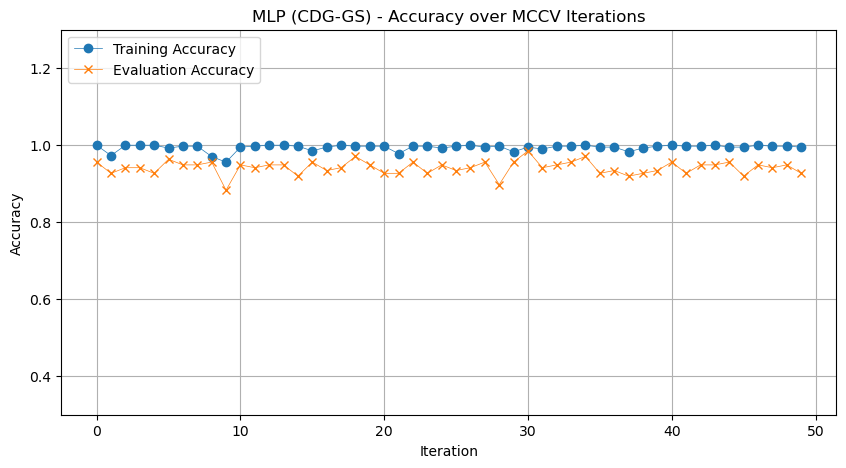

In [12]:
# Accuracy over MCCV iterations
plt.figure(figsize=(10, 5))
plt.plot(train_scores, label='Training Accuracy', marker='o', linewidth=0.5)
plt.plot(test_scores, label='Evaluation Accuracy', marker='x', linewidth=0.5)
plt.title("MLP (CDG-GS) - Accuracy over MCCV Iterations")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.legend(loc='upper left')
plt.ylim(0.3, 1.3)
plt.show()

### Log loss over MCCV iterations

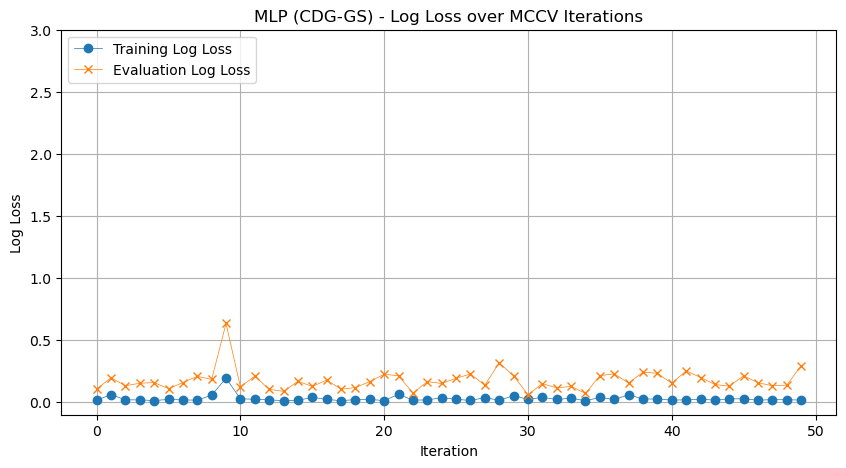

In [13]:
# Log loss over MCCV iterations
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Log Loss', marker='o', linewidth=0.5)
plt.plot(test_losses, label='Evaluation Log Loss', marker='x', linewidth=0.5)
plt.title("MLP (CDG-GS) - Log Loss over MCCV Iterations")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)
plt.legend(loc='upper left')
plt.ylim(-0.1, 3.0)
plt.show()

### Plot the average confussion matrix

In [14]:
# Function that plots the average confussion matrix
def plot_confusion_matrix(cm, labels, title="MLP (CDG-GS) MCCV - Average Confusion Matrix", cmap='Blues'):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=labels,
                yticklabels=labels)

    plt.title(title, fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

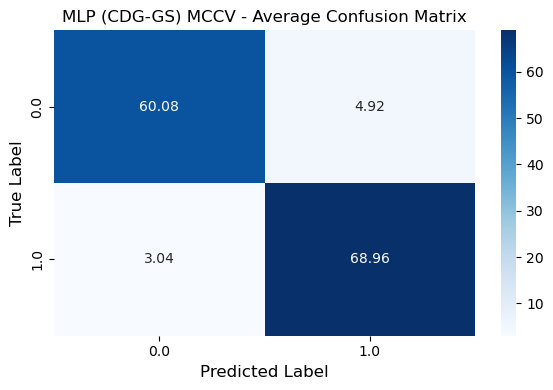

In [15]:
# Plot confusion matrix
plot_confusion_matrix(cm_avg, labels)

### End time

In [16]:
# End time
end_time = time.time()

### Elapsed time

In [17]:
# Elapsed time
elapsed_time = end_time - start_time

print(f"Elapsed time for MLP (CDG-GS): {elapsed_time:.2f} seconds")

Elapsed time for MLP (CDG-GS): 34.37 seconds
